# Predicting Customer Churn – Canadian Auto Insurance
Synthetic Dataset Construction


## Project Overview

This project aims to predict customer churn in the auto insurance industry using a synthetic dataset of Canadian customers. The objective is to identify key factors influencing churn and build machine learning models to accurately detect customers at risk of leaving.

The analysis includes exploratory data analysis (EDA), model building, evaluation, and comparison to determine the most effective approach for churn prediction.

## IMPORT LIBRARIES

In [1]:
# Core libraries for data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Sklearn - preprocessing & splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Sklearn - evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ================================
# SET RANDOM SEED
# ================================

# Ensures reproducibility of results
np.random.seed(42)

In [2]:
# Define number of synthetic customers to generate
n_customers = 10000
n_customers

10000

In [3]:
# List of Canadian provinces
provinces = ["Ontario", "Quebec", "British Columbia", "Alberta", "Manitoba",
            "Saskatchewan", "Nova Scotia", "New Brunswick",
            "Newfoundland and Labrador", "Prince Edward Island"]

# Randomly assign a province to each customer
province = np.random.choice(provinces, size = n_customers)

# Preview first 10 assigned provinces
province[:10]


array(['Nova Scotia', 'Alberta', 'New Brunswick', 'Manitoba',
       'Nova Scotia', 'Prince Edward Island', 'British Columbia',
       'Nova Scotia', 'New Brunswick', 'Manitoba'], dtype='<U25')

In [4]:
# Age group categories representing insured population segments
age_groups = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

# Probability distribution approximating realistic demographics
age_probs = [0.10, 0.22, 0.20, 0.20, 0.18, 0.10]

# Assign age group to each customer
age_group = np.random.choice(age_groups, size=n_customers, p=age_probs)

# Preview
age_group[:10]

array(['65+', '45-54', '25-34', '65+', '35-44', '25-34', '65+', '55-64',
       '55-64', '45-54'], dtype='<U5')

In [5]:
# Income band categories (mutually exclusive ranges)
income_bands = ["<40k", "40-59k", "60-79k", "80-119k", "120k+"]

# Approximate income distribution
income_probs = [0.18, 0.22, 0.22, 0.25, 0.13]

# Assign income band to each customer
income_band = np.random.choice(income_bands, size=n_customers, p=income_probs)

#preview
income_band[:10]

array(['<40k', '80-119k', '<40k', '80-119k', '60-79k', '40-59k', '60-79k',
       '40-59k', '60-79k', '80-119k'], dtype='<U7')

In [6]:
# Urban vs rural classification
urban_rural = np.random.choice(["Urban", "Rural"], size=n_customers, p = [0.82, 0.18])
urban_rural[:10]

array(['Urban', 'Urban', 'Urban', 'Rural', 'Urban', 'Rural', 'Rural',
       'Urban', 'Urban', 'Rural'], dtype='<U5')

In [7]:
# Combine all customer attributes into a dataset
df = pd.DataFrame({
    "province": province,
    "age_group": age_group,
    "income_band": income_band,
    "urban_rural": urban_rural
})
df.head()

,province,age_group,income_band,urban_rural
0,Nova Scotia,65+,<40k,Urban
1,Alberta,45-54,80-119k,Urban
2,New Brunswick,25-34,<40k,Urban
3,Manitoba,65+,80-119k,Rural
4,Nova Scotia,35-44,60-79k,Urban


In [8]:
# Tenure: years customer has stayed with the insurer (skewed toward shorter tenure)
years_options = np.arange(0, 15)
tenure_probs =  [0.219, 0.18, 0.14, 0.12, 0.10,
                 0.08, 0.06, 0.04, 0.025, 0.015,
                 0.01, 0.005, 0.003, 0.002, 0.001]

df["years_with_company"] = np.random.choice(years_options,
                           size=n_customers, p=tenure_probs )
df["years_with_company"].tail()

,years_with_company
9995,3
9996,1
9997,0
9998,0
9999,0


In [9]:
claim_options = [0, 1, 2, 3, 4, 5]
claim_probs = [0.55, 0.20, 0.12, 0.07, 0.04, 0.02]

df["claim_last_3years"] = np.random.choice(
                          claim_options,
                          size = n_customers,
                          p = claim_probs)

df["claim_last_3years"].head()

,claim_last_3years
0,0
1,0
2,0
3,1
4,4


In [10]:
# Premium increase percentage based on claims
premium_increase = []

for c in df["claim_last_3years"]:
    if c == 0:
      premium_increase.append(np.random.uniform (0, 3))
    elif c == 1:
      premium_increase.append(np.random.uniform (3, 7))
    elif c == 2:
      premium_increase.append(np.random.uniform(7, 12))
    elif c == 3:
      premium_increase.append(np.random.uniform (12, 18))
    elif c == 4:
      premium_increase.append(np.random.uniform (18, 25))
    else:
      premium_increase.append(np.random.uniform (25, 40))

print(len(premium_increase))

df["premium_increase_pct"] = np.round(premium_increase, 2)
df["premium_increase_pct"].head()


10000


,premium_increase_pct
0,0.27
1,2.58
2,1.19
3,3.53
4,22.53


In [11]:
# Satisfaction score influenced by premium increase
satisfaction = []
for p in df["premium_increase_pct"]:
  if p < 5:
    satisfaction.append(np.random.randint (8, 11))
  elif p < 10:
    satisfaction.append(np.random.randint (6, 8))
  elif p < 20:
    satisfaction.append(np.random.randint (3, 6))
  else:
    satisfaction.append(np.random.randint (1, 3))
df["satisfaction"] = satisfaction
df["satisfaction"].head()

,satisfaction
0,8
1,9
2,8
3,9
4,1


In [12]:
df.head()

,province,age_group,income_band,urban_rural,years_with_company,claim_last_3years,premium_increase_pct,satisfaction
0,Nova Scotia,65+,<40k,Urban,0,0,0.27,8
1,Alberta,45-54,80-119k,Urban,1,0,2.58,9
2,New Brunswick,25-34,<40k,Urban,5,0,1.19,8
3,Manitoba,65+,80-119k,Rural,5,1,3.53,9
4,Nova Scotia,35-44,60-79k,Urban,4,4,22.53,1


In [13]:
# Loyal if customer stayed 3 or more years
df["is_loyal_customer"] = (df["years_with_company"] >= 3).astype(int)
df[["years_with_company", "is_loyal_customer"]].head()

,years_with_company,is_loyal_customer
0,0,0
1,1,0
2,5,1
3,5,1
4,4,1


In [14]:
df.head()

,province,age_group,income_band,urban_rural,years_with_company,claim_last_3years,premium_increase_pct,satisfaction,is_loyal_customer
0,Nova Scotia,65+,<40k,Urban,0,0,0.27,8,0
1,Alberta,45-54,80-119k,Urban,1,0,2.58,9,0
2,New Brunswick,25-34,<40k,Urban,5,0,1.19,8,1
3,Manitoba,65+,80-119k,Rural,5,1,3.53,9,1
4,Nova Scotia,35-44,60-79k,Urban,4,4,22.53,1,1


In [15]:
# Churn probability based on satisfaction + loyalty
churn = []
for s, loyal in zip(df["satisfaction"], df["is_loyal_customer"]):

    base_risk = 0.05      # everyone has at least 5% chance to leave

# dissatisfaction increases risk
    if s <= 3:
      base_risk +=0.50
    elif s <=5:
      base_risk +=0.30
    elif s <=7:
      base_risk +=0.15
    else:
      base_risk +=0.05

# loyal customers are less likely to churn
    if loyal == 1:
      base_risk -=0.20

# keep probability between 0 and 1
    base_risk = max(0, min(1, base_risk))

    churn.append(np.random.binomial(1, base_risk))

df["churn"] = churn

df [["satisfaction", "is_loyal_customer", "churn"]].head()

,satisfaction,is_loyal_customer,churn
0,8,0,0
1,9,0,0
2,8,1,0
3,9,1,0
4,1,1,1


In [16]:
df.head()

,province,age_group,income_band,urban_rural,years_with_company,claim_last_3years,premium_increase_pct,satisfaction,is_loyal_customer,churn
0,Nova Scotia,65+,<40k,Urban,0,0,0.27,8,0,0
1,Alberta,45-54,80-119k,Urban,1,0,2.58,9,0,0
2,New Brunswick,25-34,<40k,Urban,5,0,1.19,8,1,0
3,Manitoba,65+,80-119k,Rural,5,1,3.53,9,1,0
4,Nova Scotia,35-44,60-79k,Urban,4,4,22.53,1,1,1


In [17]:
# Examine overall churn distribution
# This shows how many customers churned (1) vs stayed (0)
df["churn"].value_counts()

,count
churn,
0,8784
1,1216


In [18]:
# View churn as proportions instead of raw counts
df["churn"].value_counts(normalize=True)

,proportion
churn,
0,0.8784
1,0.1216


In [19]:
# Analyze churn by loyalty status
# This compares churn outcomes for loyal vs non-loyal customers
pd.crosstab(df["is_loyal_customer"], df["churn"])

churn,0,1
is_loyal_customer,,
0,4398,1007
1,4386,209


In [20]:
# Show churn proportions within each loyalty group
# Makes it easier to see if loyal customers churn less
pd.crosstab(df["is_loyal_customer"], df["churn"], normalize="index")


churn,0,1
is_loyal_customer,,
0,0.813691,0.186309
1,0.954516,0.045484


In [21]:
# Analyze churn by satisfaction level
# Groups customers by satisfaction score
# Calculates average churn rate per satisfaction level
df.groupby("satisfaction")["churn"].mean()


,churn
satisfaction,
1,0.498054
2,0.557078
3,0.438636
4,0.285393
5,0.221687
6,0.109799
7,0.113122
8,0.056364
9,0.061782


## Exploratory Data Analysis

## Target variable analysis

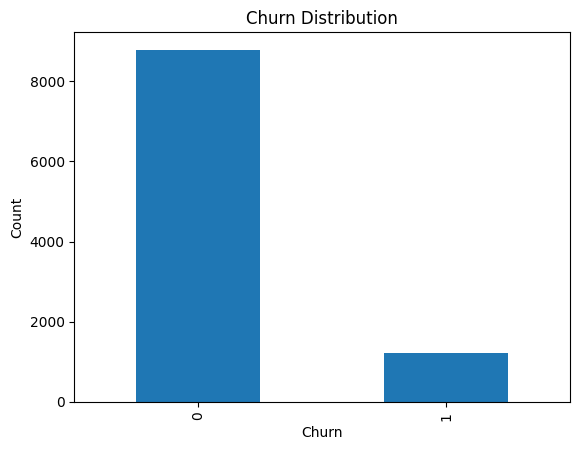

In [22]:
plt.figure()
df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()

The distribution shows that the dataset is imbalanced, with significantly more non-churn customers than churned customers.

This imbalance can affect model performance, as models may become biased toward predicting the majority class. Therefore, accuracy alone may not be a reliable evaluation metric, and metrics such as precision, recall, and F1-score — especially for the churn class — are important when assessing model performance.

## PREMIUM INCREASE AND CUSTOMER CHURN

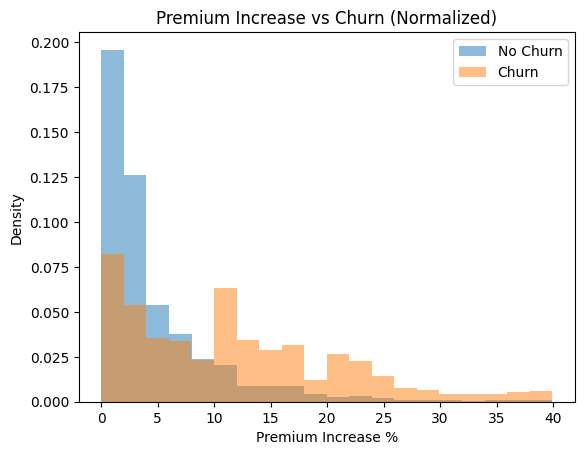

In [23]:
plt.figure()

plt.hist(df[df['churn']==0]['premium_increase_pct'],
         bins=20, alpha=0.5, label='No Churn', density=True)

plt.hist(df[df['churn']==1]['premium_increase_pct'],
         bins=20, alpha=0.5, label='Churn', density=True)

plt.legend()
plt.title('Premium Increase vs Churn (Normalized)')
plt.xlabel('Premium Increase %')
plt.ylabel('Density')
plt.show()

## The normalized distribution shows that non-churn customers are concentrated at lower premium increase levels, while churn customers are more widely distributed across higher premium increases. Although there is some overlap at lower premium levels, churn cases become more prominent as premium increases rise. This suggests that higher premium increases may be a key factor influencing customer churn.

## Impact of Customer Satisfaction on Churn

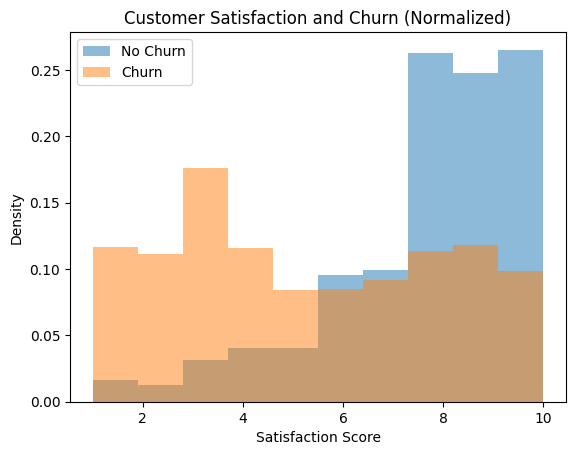

In [24]:
plt.figure()

plt.hist(df[df['churn']==0]['satisfaction'],
         bins=10, alpha=0.5, label='No Churn', density=True)

plt.hist(df[df['churn']==1]['satisfaction'],
         bins=10, alpha=0.5, label='Churn', density=True)

plt.legend()
plt.title('Customer Satisfaction and Churn (Normalized)')
plt.xlabel('Satisfaction Score')
plt.ylabel('Density')

plt.show()

Customers who churn tend to have significantly lower satisfaction scores compared to those who remain.

The distribution shows that non-churn customers are concentrated at higher satisfaction levels (7–10), while churned customers are more common at lower satisfaction levels (1–5).

This indicates that customer satisfaction is a strong predictor of churn, suggesting that improving customer experience could significantly reduce churn rates.

## IMPACT OF CUSTOMER TENURE ON CHURN (NORMALIZED)

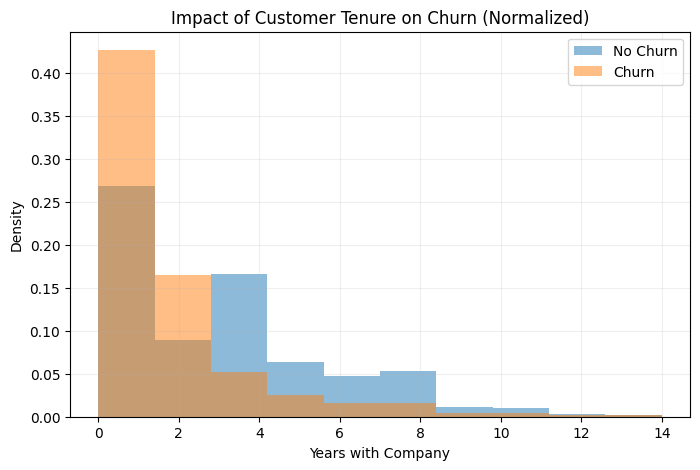

In [25]:
plt.figure(figsize=(8,5))

plt.hist(df[df['churn']==0]['years_with_company'],
         bins=10, alpha=0.5, label='No Churn', density=True)

plt.hist(df[df['churn']==1]['years_with_company'],
         bins=10, alpha=0.5, label='Churn', density=True)

plt.legend()
plt.title('Impact of Customer Tenure on Churn (Normalized)')
plt.xlabel('Years with Company')
plt.ylabel('Density')
plt.grid(alpha=0.2)

plt.show()

Customers with shorter tenure are more likely to churn, as churned customers are concentrated in the lower range of years with the company (0–2 years). In contrast, non-churn customers tend to have longer tenure, indicating that customer loyalty increases over time. This suggests that early customer engagement and retention strategies are critical in reducing churn.

### Key Insights from Exploratory Data Analysis

- The dataset is imbalanced, with significantly more non-churn customers than churned customers.
- Higher premium increases are associated with a greater likelihood of churn.
- Customers with lower satisfaction scores are more likely to churn.
- Customers with shorter tenure have a higher risk of churning.

These findings indicate that pricing, customer experience, and early customer engagement are key drivers of churn.

### FINAL MODELING AND ANALYSIS

## Data preparation

In [26]:
df_model = df.copy()

# Encode categorical variables

categorical_cols = ['province', 'age_group', 'income_band', 'urban_rural']

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

df_model.head()

,province,age_group,income_band,urban_rural,years_with_company,claim_last_3years,premium_increase_pct,satisfaction,is_loyal_customer,churn
0,5,5,4,1,0,0,0.27,8,0,0
1,0,3,3,1,1,0,2.58,9,0,0
2,3,1,4,1,5,0,1.19,8,1,0
3,2,5,3,0,5,1,3.53,9,1,0
4,5,2,2,1,4,4,22.53,1,1,1


## Data Limitations
Because this dataset is synthetic and was generated using rule-based relationships between variables such as premium increase, satisfaction, and loyalty, the results of the predictive models should be interpreted as illustrative rather than as direct evidence of real-world insurer behavior.

The purpose of this analysis is to demonstrate a realistic and reproducible churn prediction workflow while avoiding privacy concerns associated with real customer data.

## Define X and y

In [27]:
X = df_model.drop('churn', axis=1)
y = df_model['churn']

## Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

The dataset is imbalanced, with significantly more non-churn customers than churned customers. Therefore, stratified sampling is used to preserve the class distribution in both training and testing sets.

## Scaling (ONLY for Logistic Regression)

In [29]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling is applied using StandardScaler to normalize the input variables for Logistic Regression. This is important because Logistic Regression is sensitive to the scale of features, and scaling ensures that all variables contribute equally to the model.

Scaling is not required for tree-based models such as Decision Tree and Random Forest, as they are not affected by feature magnitude.

Based on the insights from the exploratory analysis, predictive models are developed to identify customers at risk of churn.

## Logistic Regression

In [30]:
# Initialize model with class balancing
log_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

# Train model
log_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate model
print("=== LOGISTIC REGRESSION ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

=== LOGISTIC REGRESSION ===
Accuracy: 0.774

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86      1757
           1       0.30      0.65      0.41       243

    accuracy                           0.77      2000
   macro avg       0.62      0.72      0.64      2000
weighted avg       0.86      0.77      0.81      2000


Confusion Matrix:
[[1390  367]
 [  85  158]]


Logistic Regression achieved an accuracy of 0.7740 and the highest recall for the churn class (0.65). This means it is the most effective model at identifying customers who are likely to churn. Although its overall accuracy is lower than the other models, recall is more important in this context due to the imbalanced dataset. Therefore, Logistic Regression is the most suitable model for this problem.

## Decision Tree

In [31]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("=== DECISION TREE ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

=== DECISION TREE ===
Accuracy: 0.8235

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.89      0.90      1757
           1       0.29      0.33      0.31       243

    accuracy                           0.82      2000
   macro avg       0.60      0.61      0.60      2000
weighted avg       0.83      0.82      0.83      2000


Confusion Matrix:
 [[1568  189]
 [ 164   79]]


The Decision Tree model achieved moderate performance, with an accuracy of 0.8235 and a recall of 0.33 for the churn class. While it performs better than Random Forest in identifying churn customers, it still misses a significant number of churn cases. This suggests that the model provides some improvement but is not optimal for accurately detecting customers at risk of churning.

## Random Forest

In [32]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("=== RANDOM FOREST ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

=== RANDOM FOREST ===
Accuracy: 0.876

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93      1757
           1       0.47      0.16      0.24       243

    accuracy                           0.88      2000
   macro avg       0.68      0.57      0.59      2000
weighted avg       0.84      0.88      0.85      2000


Confusion Matrix:
 [[1713   44]
 [ 204   39]]


Although Random Forest achieved the highest overall accuracy (0.8765), its recall for the churn class is very low (0.16). This indicates that the model fails to correctly identify a large number of customers who are likely to churn. Even after applying class balancing, the model continues to struggle with detecting the minority class. Therefore, despite its high accuracy, Random Forest is not suitable for this problem, as identifying churn customers is the primary objective.

## MODEL COMPARISON

In [33]:
# Accuracy
log_acc = accuracy_score(y_test, y_pred_log)
dt_acc = accuracy_score(y_test, y_pred_dt)
rf_acc = accuracy_score(y_test, y_pred_rf)

# Precision
log_prec = precision_score(y_test, y_pred_log, pos_label=1)
dt_prec = precision_score(y_test, y_pred_dt, pos_label=1)
rf_prec = precision_score(y_test, y_pred_rf, pos_label=1)

# Recall
log_rec = recall_score(y_test, y_pred_log, pos_label=1)
dt_rec = recall_score(y_test, y_pred_dt, pos_label=1)
rf_rec = recall_score(y_test, y_pred_rf, pos_label=1)

# F1-score
log_f1 = f1_score(y_test, y_pred_log, pos_label=1)
dt_f1 = f1_score(y_test, y_pred_dt, pos_label=1)
rf_f1 = f1_score(y_test, y_pred_rf, pos_label=1)

# Results table
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [log_acc, dt_acc, rf_acc],
    'Precision (Churn)': [log_prec, dt_prec, rf_prec],
    'Recall (Churn)': [log_rec, dt_rec, rf_rec],
    'F1-Score (Churn)': [log_f1, dt_f1, rf_f1]
})

results.sort_values(by='Recall (Churn)', ascending=False)

,Model,Accuracy,Precision (Churn),Recall (Churn),F1-Score (Churn)
0,Logistic Regression,0.7740,0.300952,0.650206,0.411458
1,Decision Tree,0.8235,0.294776,0.325103,0.309198
2,Random Forest,0.8760,0.469880,0.160494,0.239264


The model comparison shows that Logistic Regression achieved the highest recall for the churn class (0.65), making it the most effective model for identifying customers who are likely to leave.

Although Random Forest achieved the highest overall accuracy (0.876), its recall for churn is very low (0.16), meaning it fails to identify a large proportion of actual churners. In churn prediction, this is a major limitation because missing at-risk customers reduces the opportunity for proactive retention.

Precision and F1-score provide additional context. Random Forest has the highest precision, meaning its predictions are more accurate when it identifies churners. However, it identifies very few of them. Logistic Regression, while having lower precision, captures a much larger proportion of true churners, resulting in the highest F1-score among the models.

Since the primary business objective is to identify customers at risk of leaving, recall is the most important metric in this analysis.

This highlights the importance of prioritizing recall over accuracy in imbalanced classification problems, where correctly identifying minority-class cases is critical.

Therefore, Logistic Regression is the most suitable model for this business problem.

## FEATURE IMPORTANCE

In [34]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
premium_increase_pct,0.325016
satisfaction,0.128188
years_with_company,0.122563
province,0.111715
age_group,0.086652
is_loyal_customer,0.080688
income_band,0.071845
claim_last_3years,0.052038
urban_rural,0.021295


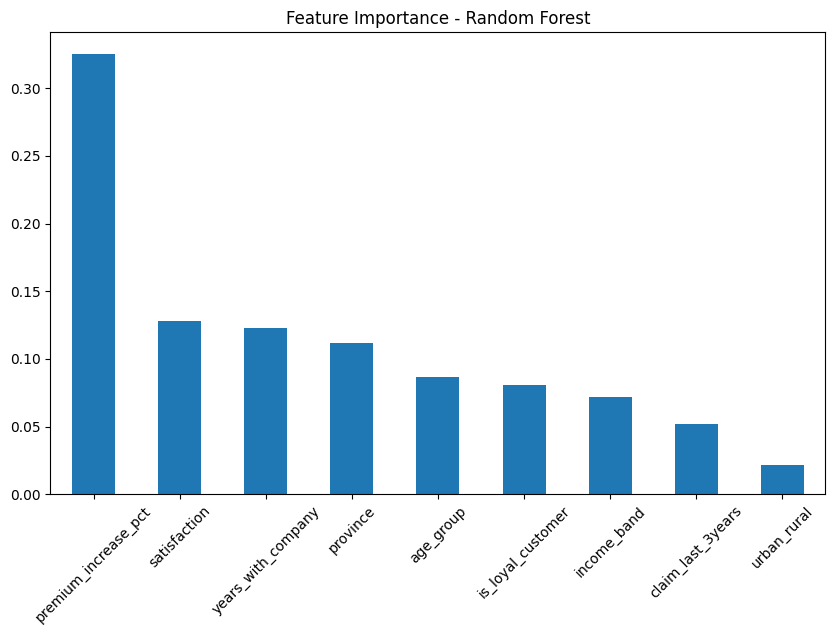

In [35]:
plt.figure(figsize=(10,6))
feature_importance.plot(kind='bar')
plt.title("Feature Importance - Random Forest")
plt.xticks(rotation=45)
plt.show()

Feature importance analysis suggests that premium increase percentage is the most influential predictor in the Random Forest model, followed by customer satisfaction and tenure.

This aligns with the earlier exploratory analysis, where higher premium increases, lower satisfaction, and shorter tenure were associated with higher churn risk.

These results should be interpreted as indicators of predictive importance within the model rather than as proof of causal relationships.

**Final Insights and Business Recommendations**

The analysis shows that customer churn is strongly influenced by premium increases, customer satisfaction, and tenure.

Customers who experience higher premium increases are significantly more likely to churn. Additionally, customers with lower satisfaction scores and shorter tenure (0–3 years) exhibit the highest churn risk.

While Random Forest achieved the highest overall accuracy (0.8765), Logistic Regression achieved the highest recall for the churn class (0.65), making it more effective at identifying customers who are likely to leave. This highlights the importance of prioritizing recall over accuracy in imbalanced classification problems, where correctly identifying minority-class cases is critical.

Therefore, Logistic Regression is the most suitable model for this business problem, as it better aligns with the goal of proactively identifying customers at risk of churn.

**Recommendations**

**Control Premium Increases**: Avoid sudden or large premium increases to reduce customer dissatisfaction and churn risk.

**Improve Customer Satisfaction**: Enhance service quality, communication, and customer support to increase retention.

**Focus on Early Customer Retention**: Implement onboarding and engagement strategies during the first 1–3 years, where churn risk is highest.

Because the dataset is synthetic and based on rule-driven relationships, the findings should be interpreted as illustrative of realistic churn behavior rather than as direct evidence from a real insurance company.